In [8]:
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import BloodMNIST
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense



In [11]:
import os

# The path where the broken file is stuck
broken_file = r"C:\Users\mules\.medmnist\bloodmnist.npz"

# Delete it if it exists
if os.path.exists(broken_file):
    os.remove(broken_file)
    print("Broken file deleted! Ready to download fresh.")
else:
    print("File already gone.")


Broken file deleted! Ready to download fresh.


100%|██████████| 35.5M/35.5M [04:53<00:00, 121kB/s] 


Using downloaded and verified file: C:\Users\mules\.medmnist\bloodmnist.npz


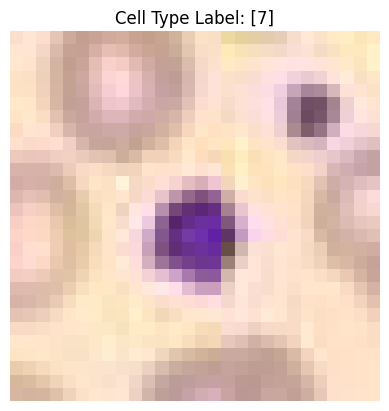

In [12]:
# Download the training and testing images
train_dataset = BloodMNIST(split='train', download=True)
test_dataset = BloodMNIST(split='test', download=True)

# Grab the very first image and its answer key
img, label = train_dataset[0]

# Show the picture!
plt.imshow(img)
plt.title(f"Cell Type Label: {label}")
plt.axis('off')
plt.show()


In [13]:
# Extract the images (X) and answer keys (Y)
x_train = train_dataset.imgs / 255.0  # We divide by 255 to crush the pixels between 0 and 1
y_train = train_dataset.labels

x_test = test_dataset.imgs / 255.0
y_test = test_dataset.labels

# Let's check the shapes!
print(f"X answers (images): {x_train.shape}")
print(f"Y answers (labels): {y_train.shape}")


X answers (images): (11959, 28, 28, 3)
Y answers (labels): (11959, 1)


In [14]:
model = Sequential()

# Eye Layer 1: The Magnifying Glass (Finds edges and colors)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)))

# Eye Layer 2: The Shrinker (Zooms out to see the bigger picture)
model.add(MaxPooling2D((2, 2)))

# Brain Layer: Flattens the 2D image into a flat line of numbers
model.add(Flatten())

# Inner Brain: Thinks about the shapes it saw
model.add(Dense(64, activation='relu'))

# Output Layer: Diagnoses the specific blood cell (BloodMNIST has 8 types)
model.add(Dense(8, activation='softmax'))

# Prepare the brain for study
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Show the blue prints!
model.summary()






Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 5408)              0         
                                                                 
 dense (Dense)               (None, 64)                346176    
                                                                 
 dense_1 (Dense)             (None, 8)                 520       
                                                                 
Total params: 347592 (1.33 MB)
Trainable params: 347592 (1.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [15]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)


Epoch 1/10


299/299 [==============================] - 3s 5ms/step - loss: 1.0788 - accuracy: 0.6174 - val_loss: 0.7313 - val_accuracy: 0.7500
Epoch 2/10
299/299 [==============================] - 1s 4ms/step - loss: 0.6595 - accuracy: 0.7733 - val_loss: 0.5640 - val_accuracy: 0.7901
Epoch 3/10
299/299 [==============================] - 1s 4ms/step - loss: 0.5374 - accuracy: 0.8151 - val_loss: 0.5381 - val_accuracy: 0.8089
Epoch 4/10
299/299 [==============================] - 1s 4ms/step - loss: 0.4664 - accuracy: 0.8409 - val_loss: 0.5234 - val_accuracy: 0.8186
Epoch 5/10
299/299 [==============================] - 1s 4ms/step - loss: 0.4215 - accuracy: 0.8537 - val_loss: 0.4049 - val_accuracy: 0.8620
Epoch 6/10
299/299 [==============================] - 1s 4ms/step - loss: 0.3795 - accuracy: 0.8631 - val_loss: 0.3933 - val_accuracy: 0.8608
Epoch 7/10
299/299 [==============================] - 1s 4ms/step - loss: 0.3455 - accuracy: 0.8809 - val_loss: 0.3721 - val_accuracy: 0.8729
Epoc

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"CNN Final Test Accuracy: {test_acc * 100:.2f}%")


107/107 [==============================] - 0s 2ms/step - loss: 0.3508 - accuracy: 0.8787
CNN Final Test Accuracy: 87.87%


1/1 [==============================] - 0s 60ms/step


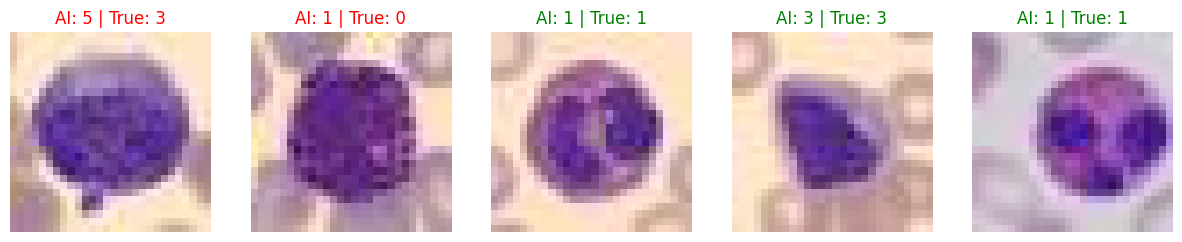

In [17]:
predictions = model.predict(x_test[:5])

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Show the cell image
    axes[i].imshow(x_test[i])
    
    # What the AI guessed vs What the real answer is
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i][0]
    
    # Green title if it got it right, Red if it made a mistake
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f"AI: {pred_label} | True: {true_label}", color=color)
    axes[i].axis('off')

plt.show()
